In [1]:
"""
Analysis of grid search experiment results.

This script loads results from results/grid_search/grid_search_results_final.json
and performs comprehensive analysis:
- Statistics by models and hyperparameters
- Visualizations (heatmaps, plots)
- Finding best configurations
"""

import json
import os
from pathlib import Path
import warnings

from matplotlib.collections import LineCollection
from matplotlib.colors import LogNorm, PowerNorm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Set plot style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
warnings.filterwarnings('ignore')

# Fixed colormap for bottleneck width gradient (used consistently across all plots)
BOTTLENECK_CMAP = 'plasma'

In [2]:
# Helper function to plot lines with gradient color based on bottleneck width
def plot_accuracy_vs_beta_with_gradient(ax, data, title, show_legend=True):
	"""
	Plot accuracy vs beta with lines colored by bottleneck width using gradient colormap.

	Parameters:
	-----------
	ax : matplotlib axis
	    The axis to plot on
	data : pandas DataFrame
	    Data containing 'beta', 'test_accuracy', and 'bottleneck_width' columns
	title : str
	    Plot title
	show_legend : bool
	    Whether to show the legend
	"""
	widths = sorted(data['bottleneck_width'].unique())
	norm = LogNorm(min(widths), max(widths))
	cmap = plt.get_cmap(BOTTLENECK_CMAP)

	all_betas = []
	all_accuracies = []
	line_handles = []

	for width in widths:
		subset = data[data['bottleneck_width'] == width].groupby('beta')['test_accuracy'].mean()
		points = np.array([subset.index.values, subset.values]).T.reshape(-1, 1, 2)
		segments = np.concatenate([points[:-1], points[1:]], axis=1)

		lc = LineCollection(segments, cmap=cmap, norm=norm, linewidth=2.5)
		lc.set_array(np.full(len(segments), width))
		ax.add_collection(lc)

		all_betas.extend(subset.index.values)
		all_accuracies.extend(subset.values)

	# Create legend handles with colors matching each bottleneck width
	for width in widths:
		color = cmap(norm(width))
		line_handles.append(
			plt.Line2D([0], [0], color=color, linewidth=2.5, label=f'Width: {width}')
		)

	# Add legend instead of colorbar
	if show_legend and line_handles:
		ax.legend(handles=line_handles, title='Bottleneck Width', loc='best')

	ax.set_xscale('log')
	ax.set_xlabel('Beta (log scale)')
	ax.set_ylabel('Test Accuracy (%)')
	ax.set_title(title)
	ax.grid(True, alpha=0.3)

	# Set axis limits based on data
	if all_betas and all_accuracies:
		ax.set_xlim(min(all_betas) * 0.9, max(all_betas) * 1.1)
		ax.set_ylim(min(all_accuracies) - 1, max(all_accuracies) + 1)


def get_notebook_dir():
	"""Get the directory containing the current notebook or script."""
	try:
		# Works in .py files
		return Path(__file__).parent.resolve()
	except NameError:
		return Path(os.getcwd()).resolve()

In [3]:
# Data paths
PROJECT_ROOT = get_notebook_dir().parent
RESULTS_PATH = PROJECT_ROOT / 'results' / 'grid_search' / 'grid_search_results_final.json'
OUTPUT_DIR = PROJECT_ROOT / 'reports' / 'grid_search' / 'analysis'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'Loading data from: results/grid_search/grid_search_results_final.json')
print(f'Results will be saved to: results/grid_search/analysis/')

Loading data from: results/grid_search/grid_search_results_final.json
Results will be saved to: results/grid_search/analysis/


In [4]:
# Load data
with open(RESULTS_PATH, 'r', encoding='utf-8') as f:
	raw_data = json.load(f)

df = pd.DataFrame(raw_data)
print(f'Loaded {len(df)} experiments')
print(f'\nColumns: {list(df.columns)}')

Loaded 528 experiments

Columns: ['model_arch', 'bottleneck_width', 'beta', 'seed', 'test_accuracy', 'final_train_loss', 'final_val_loss', 'final_train_acc', 'final_val_acc', 'final_empirical_compression', 'final_train_empirical_compression', 'final_effective_capacity_utilization', 'final_train_effective_capacity_utilization']


In [5]:
# Basic statistics
print('BASIC STATISTICS')

print(f'\nTotal experiments: {len(df)}')
print(f'\nUnique model architectures: {df["model_arch"].unique()}')
print(f'\nUnique bottleneck widths: {sorted(df["bottleneck_width"].unique())}')
print(f'\nBeta range: [{df["beta"].min()}, {df["beta"].max()}]')
print(f'\nUnique seeds: {sorted(df["seed"].unique())}')

BASIC STATISTICS

Total experiments: 528

Unique model architectures: <StringArray>
['resnet18', 'vgg11']
Length: 2, dtype: str

Unique bottleneck widths: [np.int64(16), np.int64(32), np.int64(64), np.int64(128), np.int64(256), np.int64(512), np.int64(1024), np.int64(2048)]

Beta range: [1e-08, 100.0]

Unique seeds: [np.int64(12), np.int64(42), np.int64(1984)]


In [6]:
# Statistics on test_accuracy
print('STATISTICS ON ACCURACY (test_accuracy)')

print(f'\nMean: {df["test_accuracy"].mean():.2f}%')
print(f'Median: {df["test_accuracy"].median():.2f}%')
print(f'Std. deviation: {df["test_accuracy"].std():.2f}%')
print(f'Min: {df["test_accuracy"].min():.2f}%')
print(f'Max: {df["test_accuracy"].max():.2f}%')

STATISTICS ON ACCURACY (test_accuracy)

Mean: 55.18%
Median: 83.16%
Std. deviation: 35.46%
Min: 9.30%
Max: 86.25%


In [7]:
# Best configurations
print('BEST CONFIGURATIONS (by test_accuracy)')

top_configs = df.nlargest(10, 'test_accuracy')
for _, row in top_configs.iterrows():
	print(
		f'\nTest Acc: {row["test_accuracy"]:.2f}% | '
		f'Model: {row["model_arch"]} | '
		f'Width: {row["bottleneck_width"]} | '
		f'Beta: {row["beta"]:.6f} | '
		f'Seed: {row["seed"]}'
	)

BEST CONFIGURATIONS (by test_accuracy)

Test Acc: 86.25% | Model: vgg11 | Width: 256 | Beta: 0.000000 | Seed: 1984

Test Acc: 86.20% | Model: vgg11 | Width: 128 | Beta: 0.000001 | Seed: 12

Test Acc: 86.18% | Model: vgg11 | Width: 128 | Beta: 0.000100 | Seed: 12

Test Acc: 86.06% | Model: vgg11 | Width: 128 | Beta: 0.000000 | Seed: 1984

Test Acc: 86.06% | Model: vgg11 | Width: 256 | Beta: 0.000001 | Seed: 42

Test Acc: 86.02% | Model: vgg11 | Width: 256 | Beta: 0.000100 | Seed: 1984

Test Acc: 86.01% | Model: vgg11 | Width: 128 | Beta: 0.000001 | Seed: 42

Test Acc: 86.01% | Model: vgg11 | Width: 256 | Beta: 0.000000 | Seed: 1984

Test Acc: 86.01% | Model: vgg11 | Width: 512 | Beta: 0.000000 | Seed: 12

Test Acc: 86.00% | Model: vgg11 | Width: 256 | Beta: 0.000010 | Seed: 12


In [8]:
# Aggregated statistics by architecture
print('STATISTICS BY MODEL ARCHITECTURES')

arch_stats = df.groupby('model_arch').agg(
	{
		'test_accuracy': ['mean', 'std', 'min', 'max', 'count'],
		'final_train_loss': 'mean',
		'final_val_loss': 'mean',
	}
)
print(arch_stats.round(2))

STATISTICS BY MODEL ARCHITECTURES
           test_accuracy                           final_train_loss  \
                    mean    std   min    max count             mean   
model_arch                                                            
resnet18           62.90  32.55   9.3  84.65   264            89.17   
vgg11              47.47  36.61  10.0  86.25   264            92.11   

           final_val_loss  
                     mean  
model_arch                 
resnet18             1.13  
vgg11               17.64  


In [9]:
# Aggregated statistics by bottleneck width
print('STATISTICS BY BOTTLENECK WIDTH')
width_stats = df.groupby('bottleneck_width').agg(
	{
		'test_accuracy': ['mean', 'std', 'min', 'max'],
		'final_train_loss': 'mean',
		'final_val_loss': 'mean',
		'final_empirical_compression': 'mean',
	}
)
print(width_stats.round(2))

STATISTICS BY BOTTLENECK WIDTH
                 test_accuracy                      final_train_loss  \
                          mean    std    min    max             mean   
bottleneck_width                                                       
16                       40.26  32.96  10.00  83.54            90.18   
32                       50.51  36.33  10.00  85.07            90.91   
64                       55.80  36.02  10.00  85.97            89.96   
128                      57.54  36.08  10.00  86.20            89.39   
256                      60.30  34.51   9.94  86.25            91.50   
512                      58.40  35.37   9.30  86.01            90.71   
1024                     59.09  34.83  10.00  85.88            91.72   
2048                     59.58  34.72  10.00  85.92            90.56   

                 final_val_loss final_empirical_compression  
                           mean                        mean  
bottleneck_width                                    

In [10]:
print('EFFECT OF BETA ON ACCURACY')
beta_stats = df.groupby('beta').agg(
	{
		'test_accuracy': ['mean', 'std', 'min', 'max', 'count'],
		'final_train_loss': 'mean',
		'final_val_loss': 'mean',
	}
)
print(beta_stats.round(2))

EFFECT OF BETA ON ACCURACY
             test_accuracy                            final_train_loss  \
                      mean    std    min    max count             mean   
beta                                                                     
1.000000e-08         77.74  20.14  10.00  86.06    48             0.36   
1.000000e-07         81.98   9.62  32.13  86.25    48             0.27   
1.000000e-06         80.70  13.44  10.00  86.20    48             0.30   
1.000000e-05         80.91  13.51  10.00  86.00    48             0.29   
1.000000e-04         82.97   5.30  55.42  86.18    48             0.26   
1.000000e-03         73.89  24.95  10.00  85.92    48             0.49   
1.000000e-02         54.52  36.42  10.00  85.78    48             1.10   
1.000000e-01         39.32  35.99  10.00  84.19    48             2.28   
1.000000e+00         14.11  12.24  10.00  66.66    48            10.93   
1.000000e+01         10.67   1.67   9.30  19.64    48            89.62   
1.000000e+0

BUILDING PLOTS
Saved: heatmap_accuracy_width_beta.png


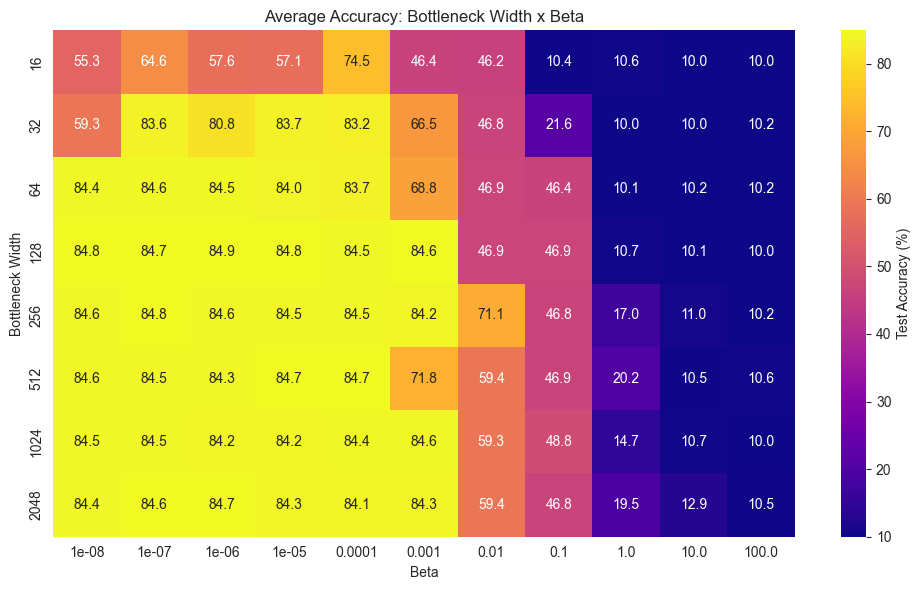

In [11]:
# Building heatmaps
print('BUILDING PLOTS')
beta_filtered = df.copy()
fig, ax = plt.subplots(figsize=(10, 6))
pivot_acc = beta_filtered.pivot_table(
	values='test_accuracy',
	index='bottleneck_width',
	columns='beta',
	aggfunc='mean',
)
sns.heatmap(
	pivot_acc,
	annot=True,
	fmt='.1f',
	cmap=BOTTLENECK_CMAP,
	ax=ax,
	cbar_kws={'label': 'Test Accuracy (%)'},
)
ax.set_title('Average Accuracy: Bottleneck Width x Beta')
ax.set_xlabel('Beta')
ax.set_ylabel('Bottleneck Width')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'heatmap_accuracy_width_beta.png', dpi=150)
print(f'Saved: heatmap_accuracy_width_beta.png')
plt.show()

Saved: heatmap_loss_width_beta.png


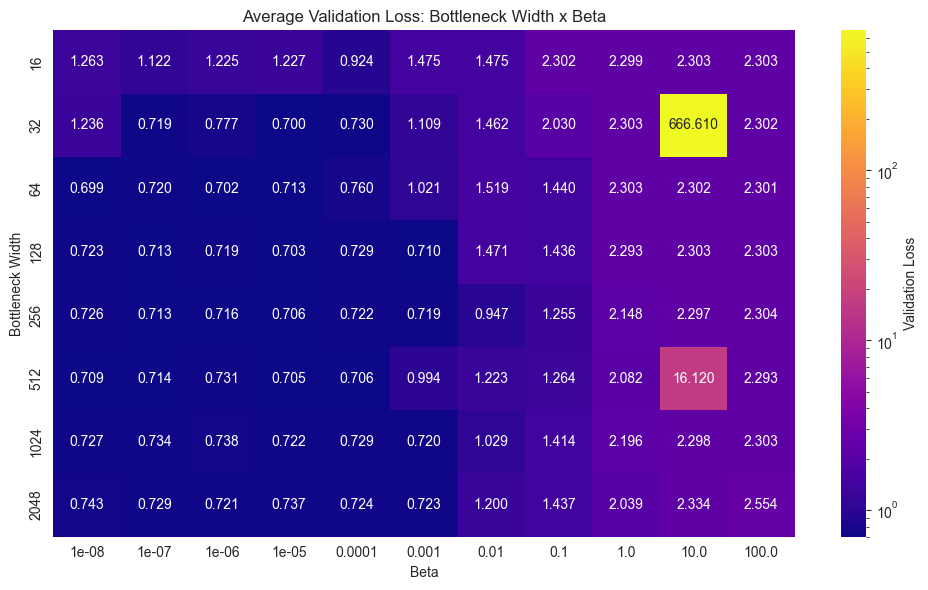

In [12]:
# 2. Heatmap: bottleneck_width x beta -> final_val_loss
fig, ax = plt.subplots(figsize=(10, 6))
pivot_loss = beta_filtered.pivot_table(
	values='final_val_loss',
	index='bottleneck_width',
	columns='beta',
	aggfunc='mean',
)
# Filter out infinite values for colorbar scale
finite_values = pivot_loss.values[np.isfinite(pivot_loss.values)]
vmin_loss = np.min(finite_values)
vmax_loss = np.max(finite_values)

# Ensure vmin is positive for LogNorm
if vmin_loss <= 0:
	vmin_loss = vmin_loss * 0.9 if vmin_loss < 0 else vmax_loss * 0.01

# Use LogNorm for better handling of outliers - compresses high values more aggressively
norm_loss = LogNorm(vmin=vmin_loss, vmax=vmax_loss)

sns.heatmap(
	pivot_loss,
	annot=True,
	fmt='.3f',
	cmap=BOTTLENECK_CMAP,
	ax=ax,
	norm=norm_loss,
	cbar_kws={'label': 'Validation Loss'},
)
ax.set_title('Average Validation Loss: Bottleneck Width x Beta')
ax.set_xlabel('Beta')
ax.set_ylabel('Bottleneck Width')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'heatmap_loss_width_beta.png', dpi=150)
print(f'Saved: heatmap_loss_width_beta.png')
plt.show()

Saved: heatmap_compression_width_beta.png


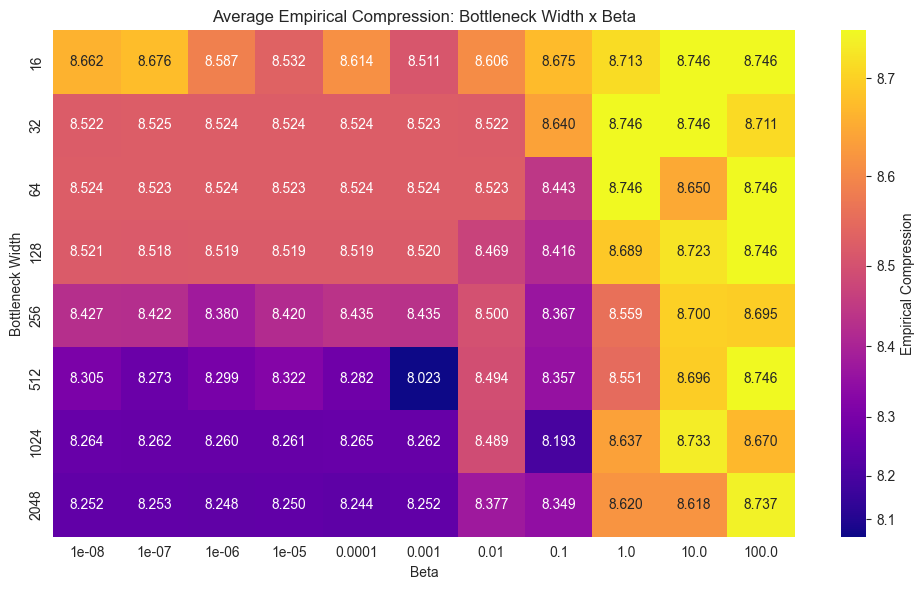

In [13]:
# 3. Heatmap: bottleneck_width x beta -> final_empirical_compression
fig, ax = plt.subplots(figsize=(10, 6))
pivot_comp = beta_filtered.pivot_table(
	values='final_empirical_compression',
	index='bottleneck_width',
	columns='beta',
	aggfunc='mean',
)
# Filter out infinite values for colorbar scale
finite_comp = pivot_comp.values[np.isfinite(pivot_comp.values)]
vmin_comp = np.min(finite_comp)
vmax_comp = np.max(finite_comp)

# Ensure vmin is positive for PowerNorm
if vmin_comp <= 0:
	vmin_comp = vmin_comp * 0.9 if vmin_comp < 0 else vmax_comp * 0.01

# Use PowerNorm with gamma=1.5 to expand differences in higher values (8-9)
# while still showing outliers (4-5) with compressed color range
norm_comp = PowerNorm(gamma=1.5, vmin=vmin_comp, vmax=vmax_comp)

sns.heatmap(
	pivot_comp,
	annot=True,
	fmt='.3f',
	cmap=BOTTLENECK_CMAP,
	ax=ax,
	norm=norm_comp,
	cbar_kws={'label': 'Empirical Compression'},
)
ax.set_title('Average Empirical Compression: Bottleneck Width x Beta')
ax.set_xlabel('Beta')
ax.set_ylabel('Bottleneck Width')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'heatmap_compression_width_beta.png', dpi=150)
print(f'Saved: heatmap_compression_width_beta.png')
plt.show()

Saved: heatmap_capacity_width_beta.png


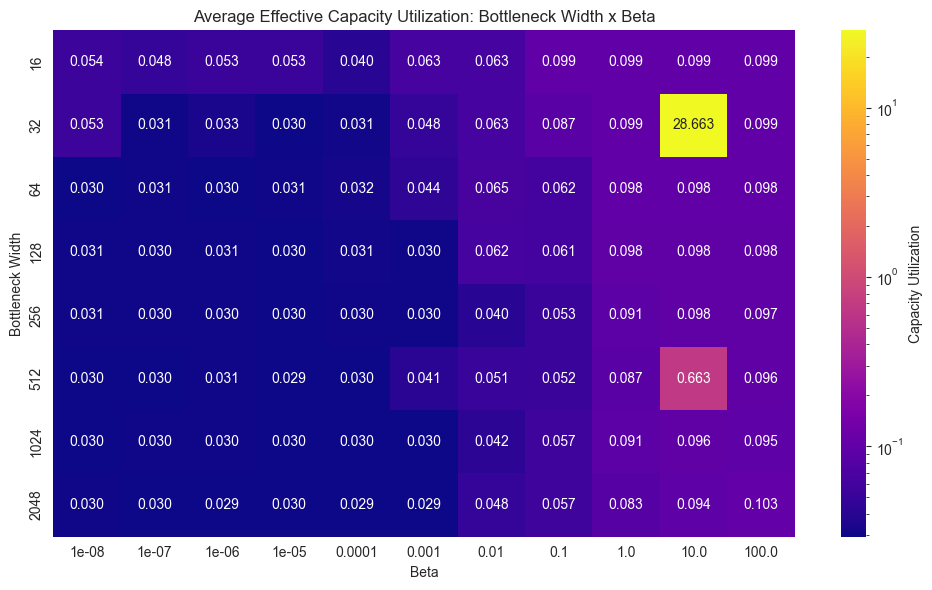

In [14]:
# 4. Heatmap: bottleneck_width x beta -> final_effective_capacity_utilization
fig, ax = plt.subplots(figsize=(10, 6))
pivot_cap = beta_filtered.pivot_table(
	values='final_effective_capacity_utilization',
	index='bottleneck_width',
	columns='beta',
	aggfunc='mean',
)
# Filter out infinite values for colorbar scale
finite_cap = pivot_cap.values[np.isfinite(pivot_cap.values)]
vmin_cap = np.min(finite_cap)
vmax_cap = np.max(finite_cap)

# Ensure vmin is positive for LogNorm
if vmin_cap <= 0:
	vmin_cap = vmin_cap * 0.9 if vmin_cap < 0 else vmax_cap * 0.01

norm_cap = LogNorm(vmin=vmin_cap, vmax=vmax_cap)

sns.heatmap(
	pivot_cap,
	annot=True,
	fmt='.3f',
	cmap=BOTTLENECK_CMAP,
	ax=ax,
	norm=norm_cap,
	cbar_kws={'label': 'Capacity Utilization'},
)
ax.set_title('Average Effective Capacity Utilization: Bottleneck Width x Beta')
ax.set_xlabel('Beta')
ax.set_ylabel('Bottleneck Width')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'heatmap_capacity_width_beta.png', dpi=150)
print(f'Saved: heatmap_capacity_width_beta.png')
plt.show()

Saved: scatter_acc_compression_capacity.png


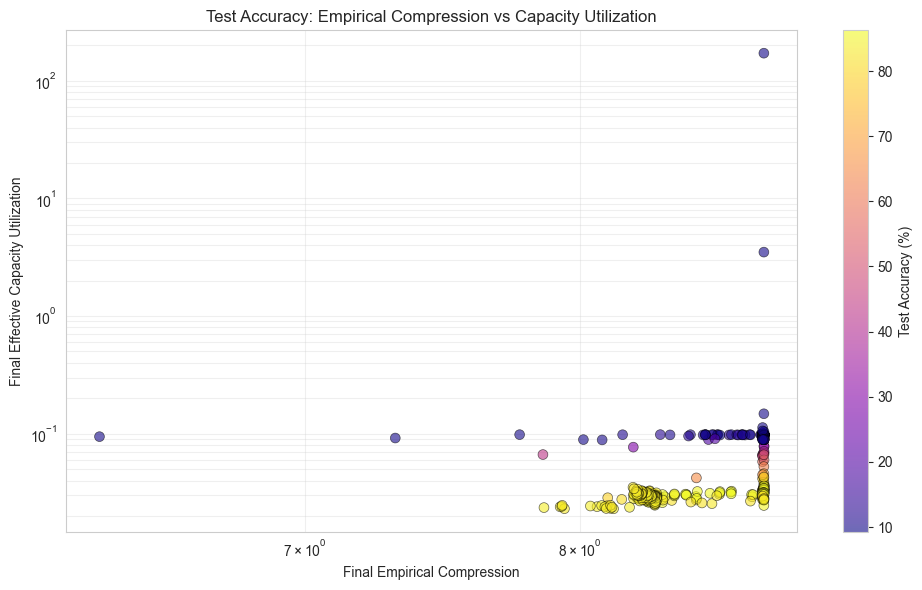

In [15]:
# 5. Scatter plot: Empirical Compression vs Capacity Utilization (color = test accuracy)
fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(
	beta_filtered['final_empirical_compression'],
	beta_filtered['final_effective_capacity_utilization'],
	c=beta_filtered['test_accuracy'],
	cmap=BOTTLENECK_CMAP,
	alpha=0.6,
	s=50,
	edgecolors='black',
	linewidth=0.5,
)
ax.set_xlabel('Final Empirical Compression')
ax.set_ylabel('Final Effective Capacity Utilization')
ax.set_title('Test Accuracy: Empirical Compression vs Capacity Utilization')
ax.set_xscale('log')
ax.set_yscale('log')
ax.grid(True, alpha=0.3, which='both')
cbar = plt.colorbar(scatter)
cbar.set_label('Test Accuracy (%)')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'scatter_acc_compression_capacity.png', dpi=150)
print(f'Saved: scatter_acc_compression_capacity.png')
plt.show()

Saved: scatter_acc_compression.png


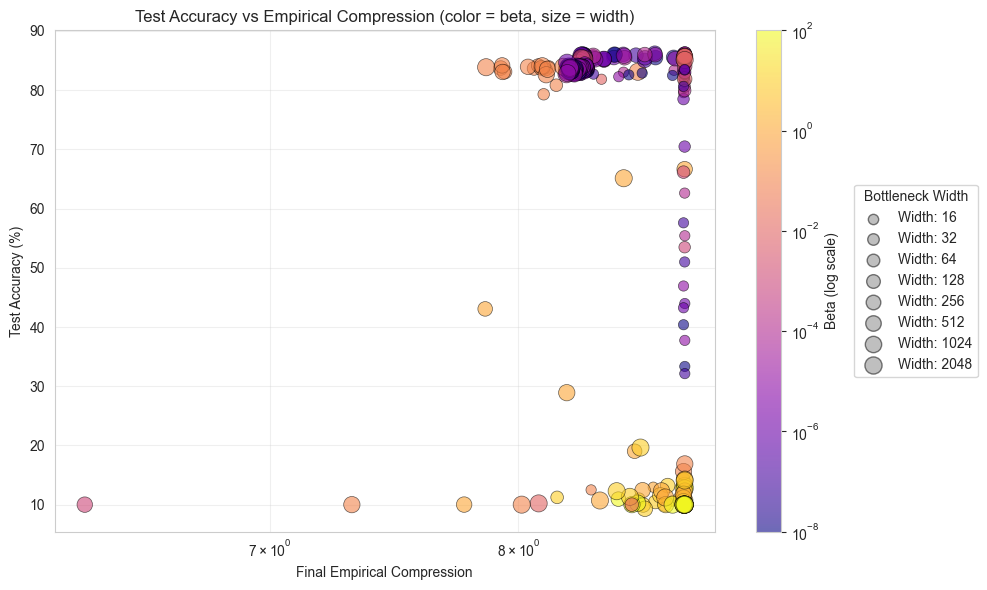

In [16]:
# 6. Scatter plot: Empirical Compression vs Test Accuracy (color = beta, size = bottleneck width)
fig, ax = plt.subplots(figsize=(10, 6))
beta_min = beta_filtered['beta'].min()
beta_max = beta_filtered['beta'].max()
# Ensure beta_min is positive for LogNorm
if beta_min <= 0:
	beta_min = beta_min * 0.9 if beta_min < 0 else beta_max * 0.01

# Scale size by log of bottleneck width
widths = beta_filtered['bottleneck_width']
sizes = np.log(widths) * 20  # Scale factor for visibility

scatter = ax.scatter(
	beta_filtered['final_empirical_compression'],
	beta_filtered['test_accuracy'],
	c=beta_filtered['beta'],
	norm=LogNorm(beta_min, beta_max),
	cmap=BOTTLENECK_CMAP,
	s=sizes,
	alpha=0.6,
	edgecolors='black',
	linewidth=0.5,
)
ax.set_xlabel('Final Empirical Compression')
ax.set_ylabel('Test Accuracy (%)')
ax.set_title('Test Accuracy vs Empirical Compression (color = beta, size = width)')
ax.set_xscale('log')
ax.grid(True, alpha=0.3, which='both')
cbar = plt.colorbar(scatter)
cbar.set_label('Beta (log scale)')

# Add size legend outside the plot near colorbar
unique_widths = sorted(widths.unique())
legend_sizes = [np.log(w) * 20 for w in unique_widths]
legend_handles = [
	plt.scatter([], [], s=s, color='gray', alpha=0.5, edgecolors='black', label=f'Width: {w}')
	for w, s in zip(unique_widths, legend_sizes)
]
ax.legend(
	handles=legend_handles, title='Bottleneck Width', loc='center left', bbox_to_anchor=(1.2, 0.5)
)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'scatter_acc_compression.png', dpi=150)
print(f'Saved: scatter_acc_compression.png')
plt.show()

Saved: accuracy_vs_beta.png


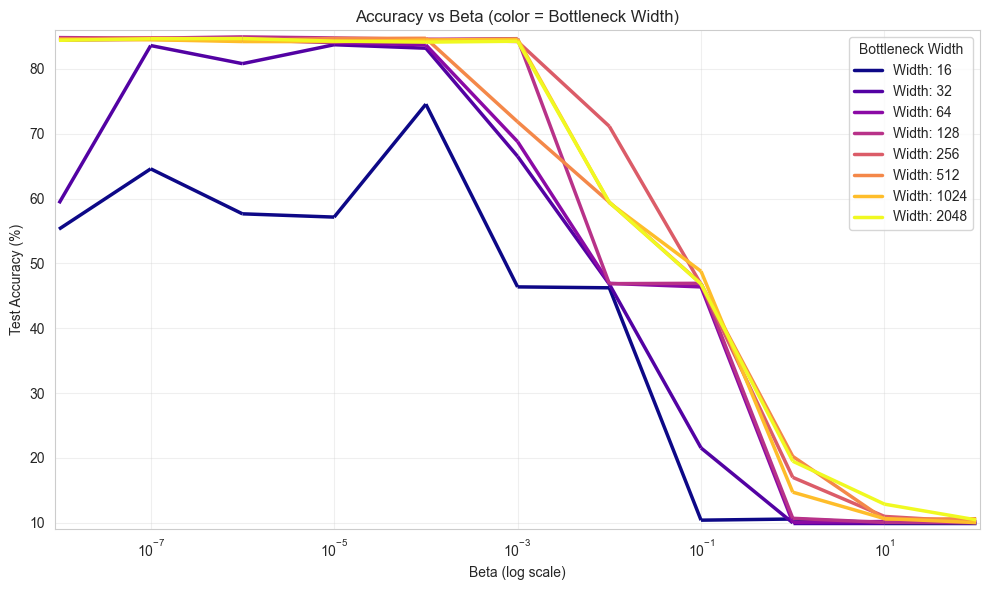

In [17]:
# 7. Accuracy vs beta with gradient color based on bottleneck width (unified style)
fig, ax = plt.subplots(figsize=(10, 6))
plot_accuracy_vs_beta_with_gradient(
	ax, beta_filtered, 'Accuracy vs Beta (color = Bottleneck Width)'
)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'accuracy_vs_beta.png', dpi=150)
print(f'Saved: accuracy_vs_beta.png')
plt.show()

Saved: accuracy_distribution.png


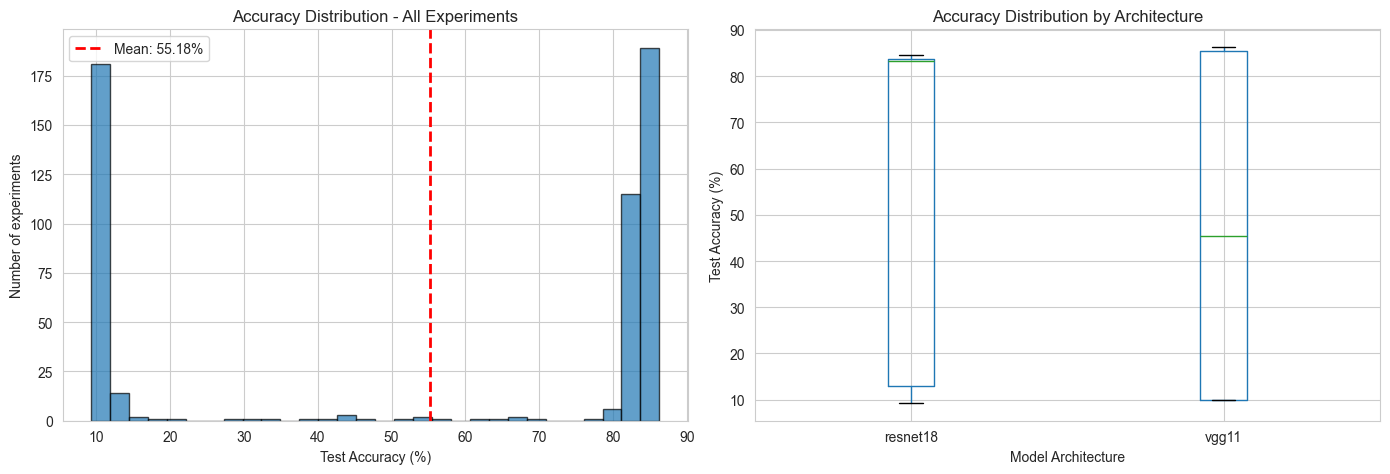

In [18]:
# 4. Accuracy distribution by model
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
ax = axes[0]
ax.hist(df['test_accuracy'], bins=30, edgecolor='black', alpha=0.7)
ax.axvline(
	df['test_accuracy'].mean(),
	color='red',
	linestyle='--',
	linewidth=2,
	label=f'Mean: {df["test_accuracy"].mean():.2f}%',
)
ax.set_xlabel('Test Accuracy (%)')
ax.set_ylabel('Number of experiments')
ax.set_title('Accuracy Distribution - All Experiments')
ax.legend()

# Box plot by architecture
ax = axes[1]
df.boxplot(column='test_accuracy', by='model_arch', ax=ax)
ax.set_xlabel('Model Architecture')
ax.set_ylabel('Test Accuracy (%)')
ax.set_title('Accuracy Distribution by Architecture')
plt.suptitle('')  # Remove automatic title
plt.tight_layout()

plt.savefig(OUTPUT_DIR / 'accuracy_distribution.png', dpi=150)
print(f'Saved: accuracy_distribution.png')
plt.show()

Saved: train_vs_val_loss.png


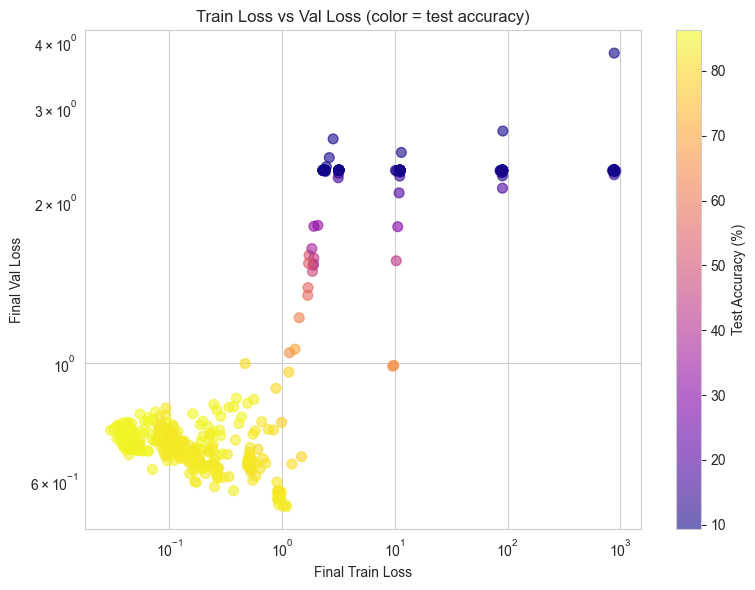

In [19]:
# 5. Train loss vs val loss relationship
fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(
	df['final_train_loss'],
	df['final_val_loss'],
	c=df['test_accuracy'],
	cmap=BOTTLENECK_CMAP,
	alpha=0.6,
	s=50,
)
ax.set_xlabel('Final Train Loss')
ax.set_ylabel('Final Val Loss')
ax.set_title('Train Loss vs Val Loss (color = test accuracy)')
ax.set_xscale('log')
ax.set_yscale('log')
cbar = plt.colorbar(scatter)
cbar.set_label('Test Accuracy (%)')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'train_vs_val_loss.png', dpi=150)
print(f'Saved: train_vs_val_loss.png')
plt.show()

Saved: compression_metrics.png


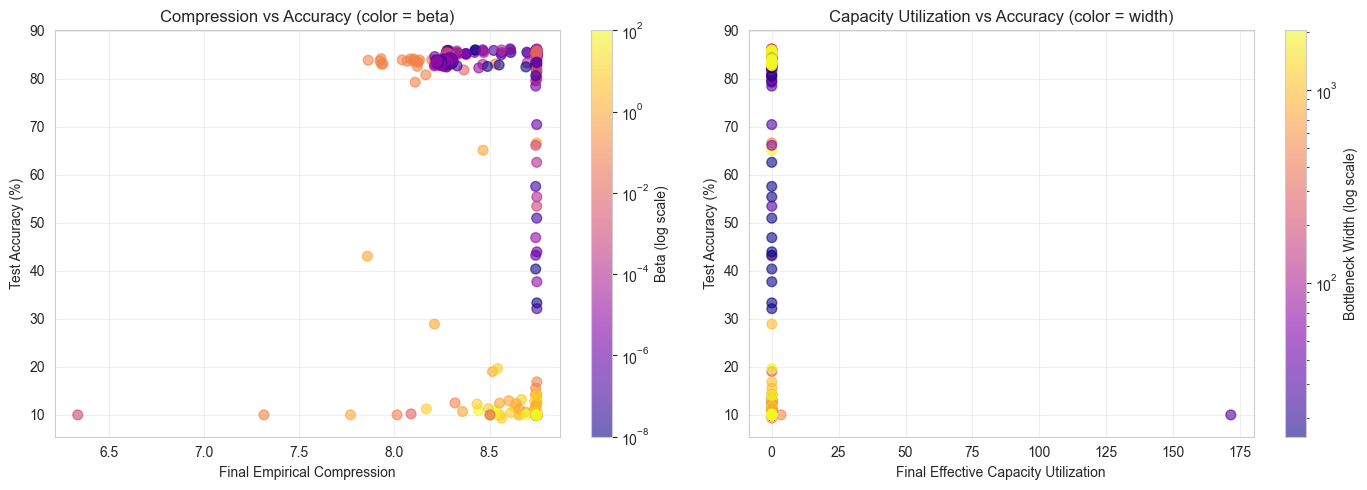

In [20]:
# 6. Compression metrics analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
scatter = ax.scatter(
	df['final_empirical_compression'],
	df['test_accuracy'],
	c=df['beta'],
	norm=LogNorm(df['beta'].min(), df['beta'].max()),
	cmap=BOTTLENECK_CMAP,
	alpha=0.6,
	s=50,
)
ax.set_xlabel('Final Empirical Compression')
ax.set_ylabel('Test Accuracy (%)')
ax.set_title('Compression vs Accuracy (color = beta)')
cbar = plt.colorbar(scatter)
cbar.set_label('Beta (log scale)')
ax.grid(True, alpha=0.3)

ax = axes[1]
scatter = ax.scatter(
	df['final_effective_capacity_utilization'],
	df['test_accuracy'],
	c=df['bottleneck_width'],
	norm=LogNorm(df['bottleneck_width'].min(), df['bottleneck_width'].max()),
	cmap=BOTTLENECK_CMAP,
	alpha=0.6,
	s=50,
)
ax.set_xlabel('Final Effective Capacity Utilization')
ax.set_ylabel('Test Accuracy (%)')
ax.set_title('Capacity Utilization vs Accuracy (color = width)')
cbar = plt.colorbar(scatter)
cbar.set_label('Bottleneck Width (log scale)')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'compression_metrics.png', dpi=150)
print(f'Saved: compression_metrics.png')
plt.show()

ANALYSIS BY MODEL ARCHITECTURE

--- resnet18 ---
  Experiments: 264
  Mean accuracy: 62.90%
  Best accuracy: 84.65%
  Saved: heatmap_accuracy_resnet18.png


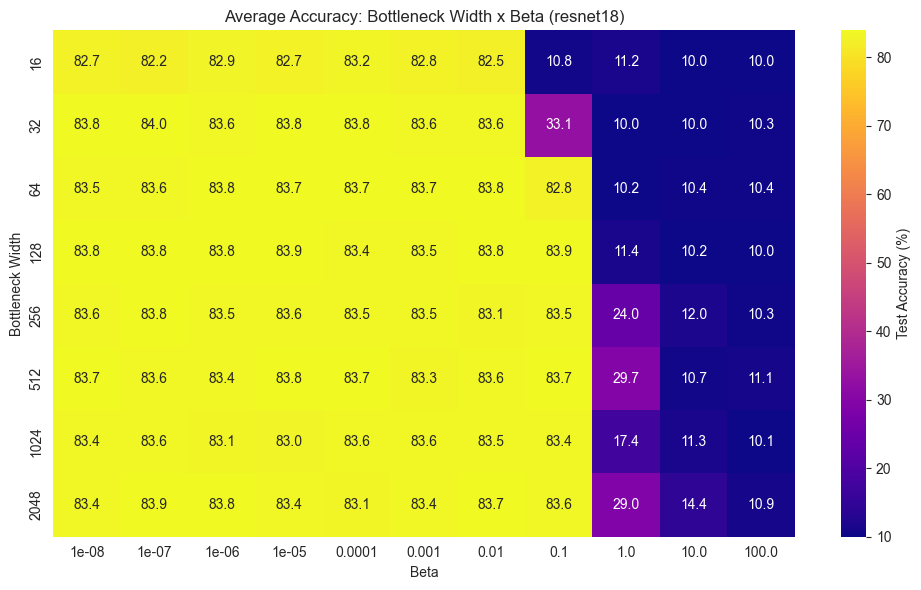

  Saved: heatmap_loss_resnet18.png


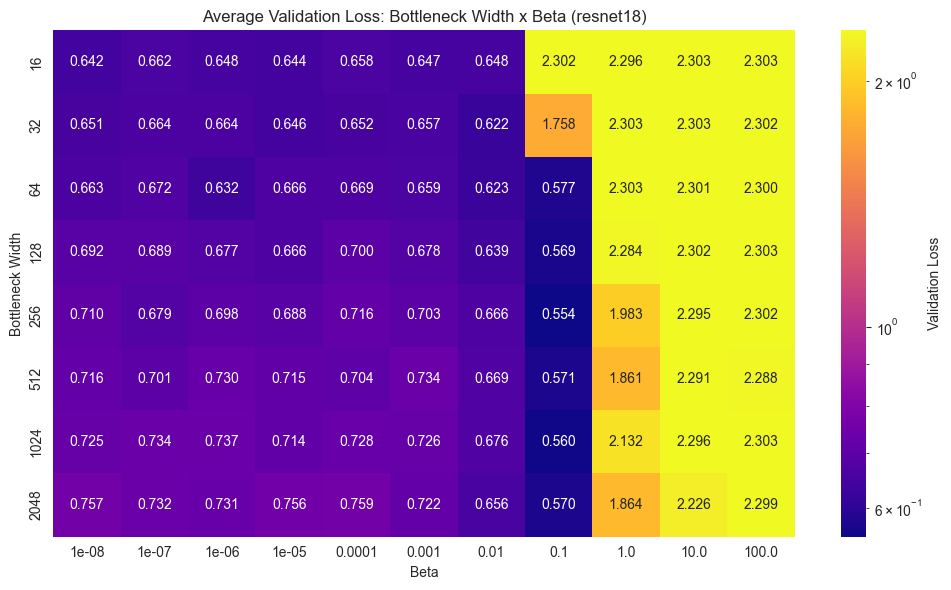

  Saved: heatmap_compression_resnet18.png


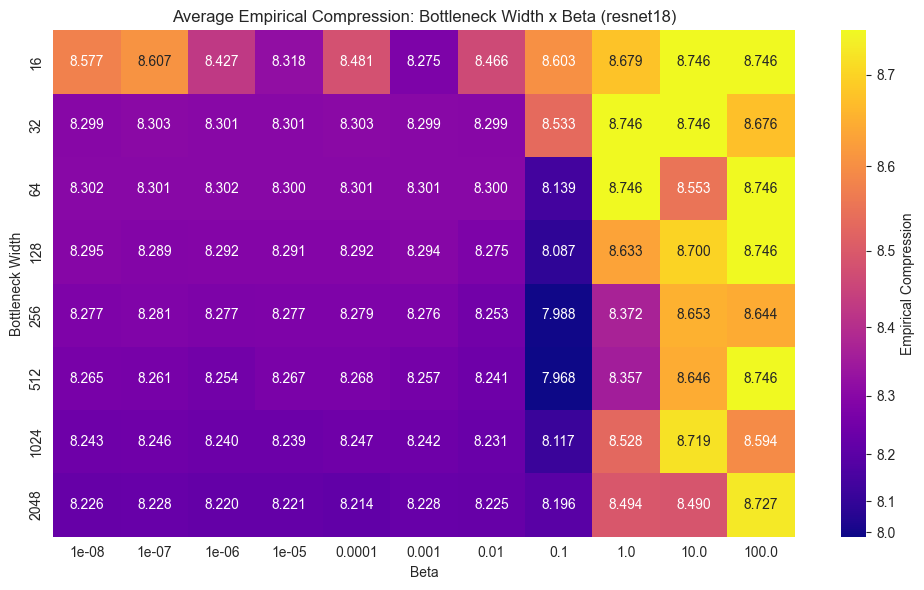

  Saved: heatmap_capacity_resnet18.png


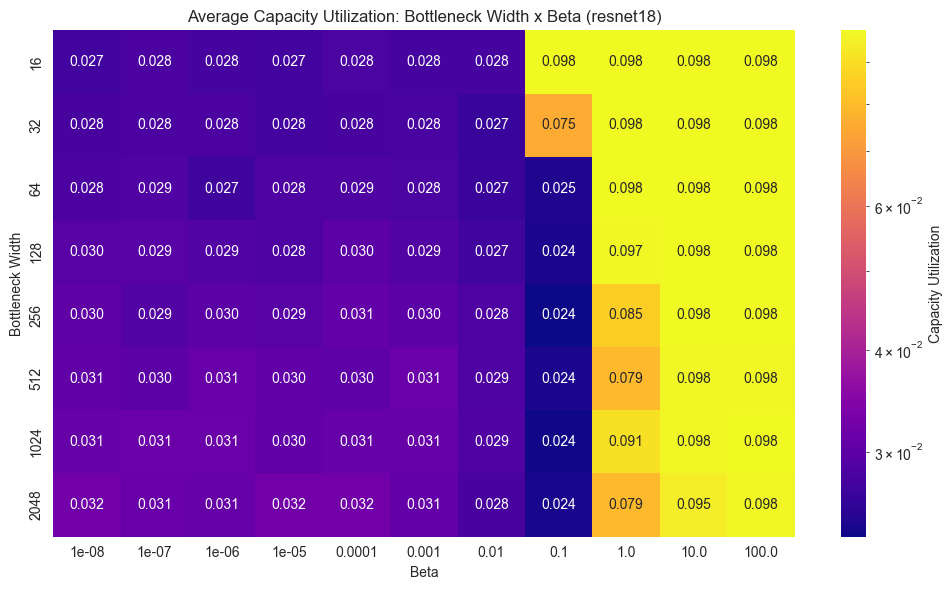

  Saved: scatter_acc_compression_capacity_resnet18.png


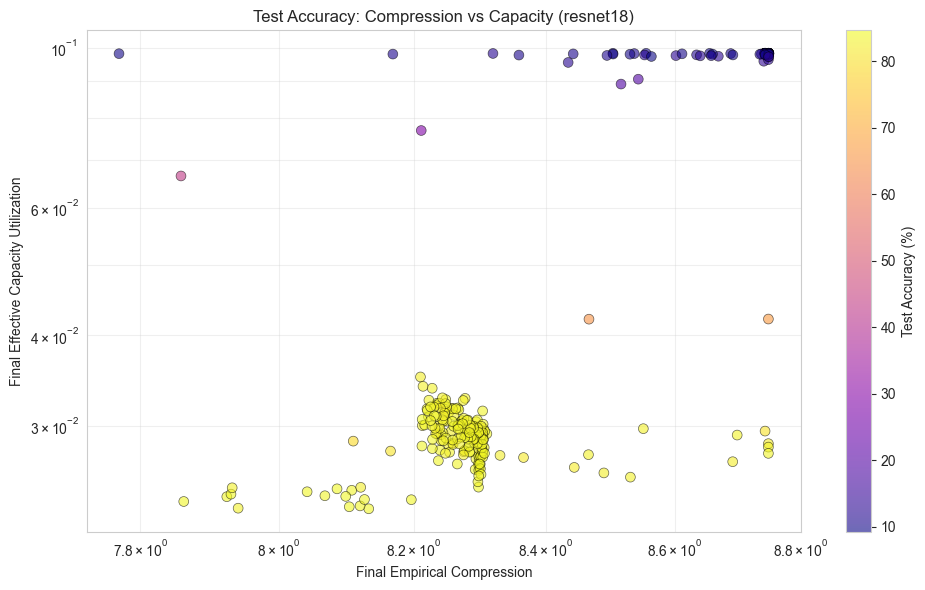

  Saved: scatter_acc_compression_resnet18.png


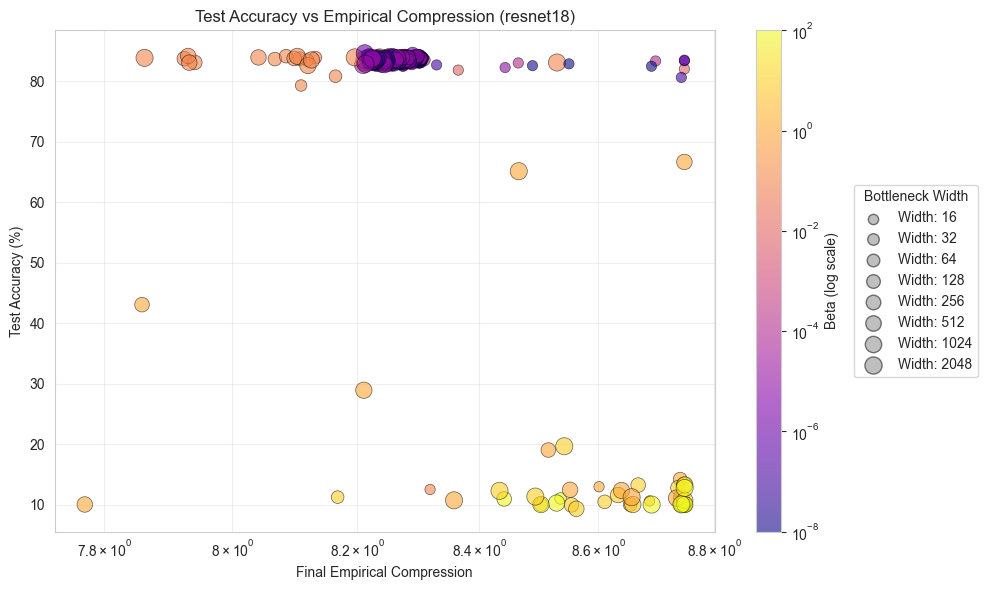

  Saved: accuracy_vs_beta_resnet18.png


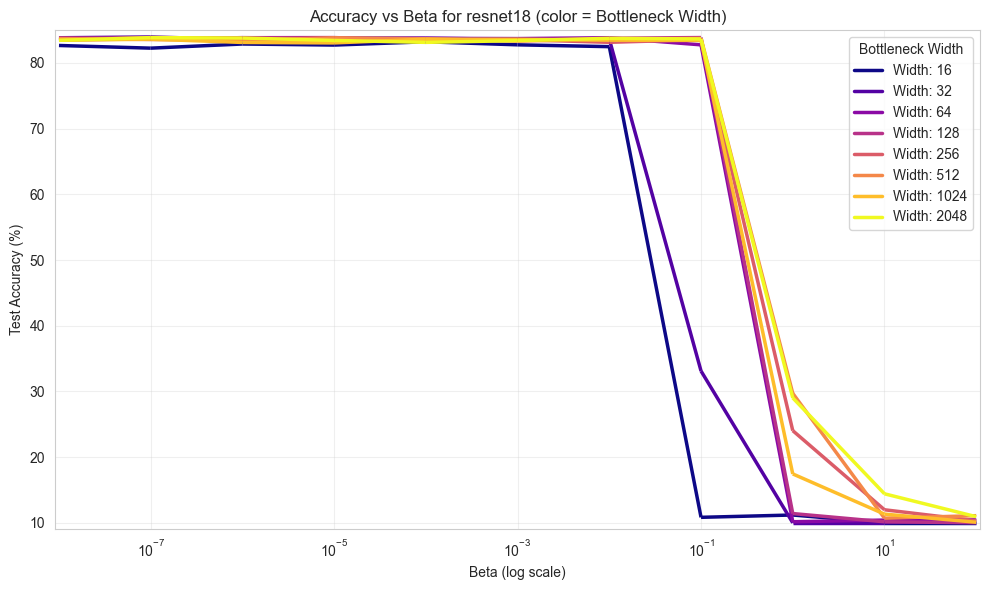


--- vgg11 ---
  Experiments: 264
  Mean accuracy: 47.47%
  Best accuracy: 86.25%
  Saved: heatmap_accuracy_vgg11.png


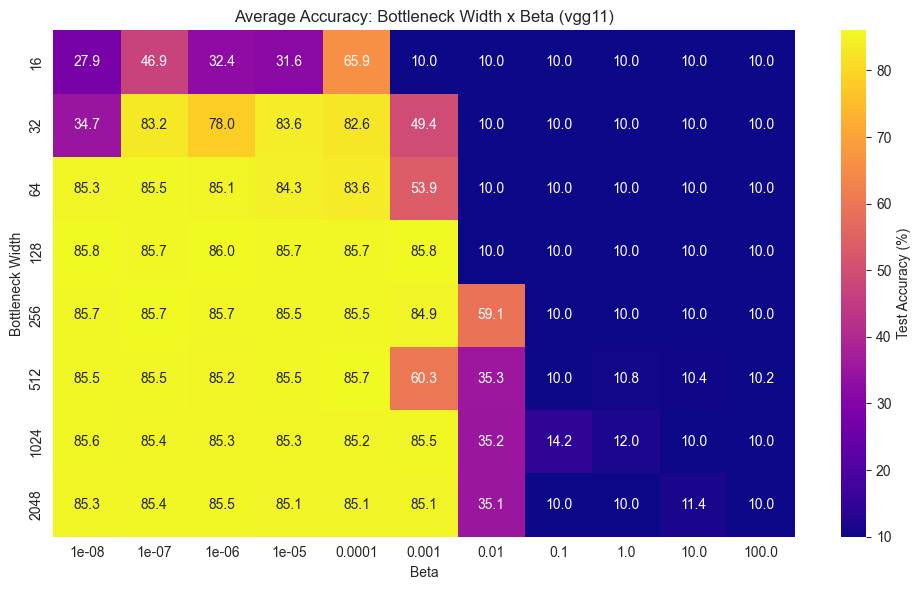

  Saved: heatmap_loss_vgg11.png


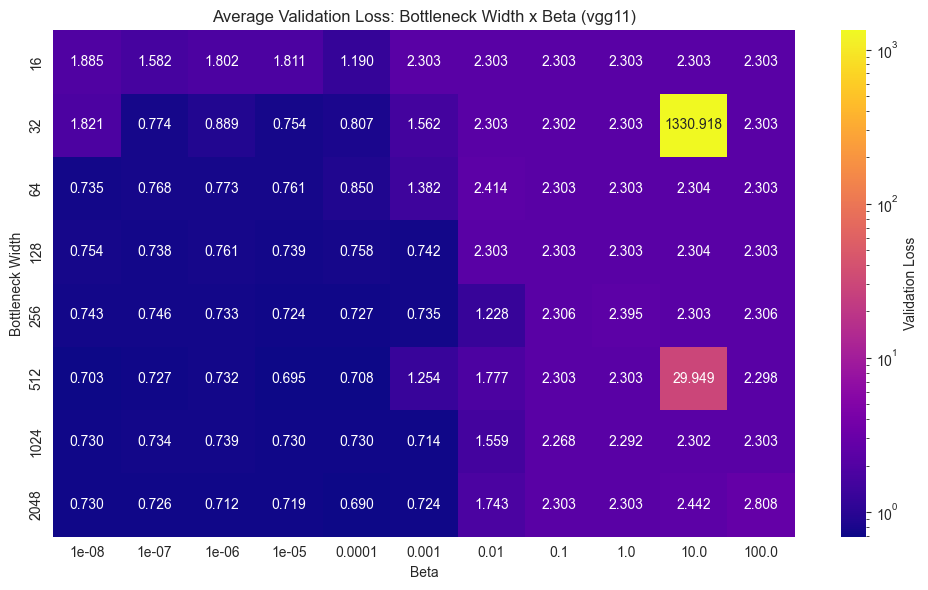

  Saved: heatmap_compression_vgg11.png


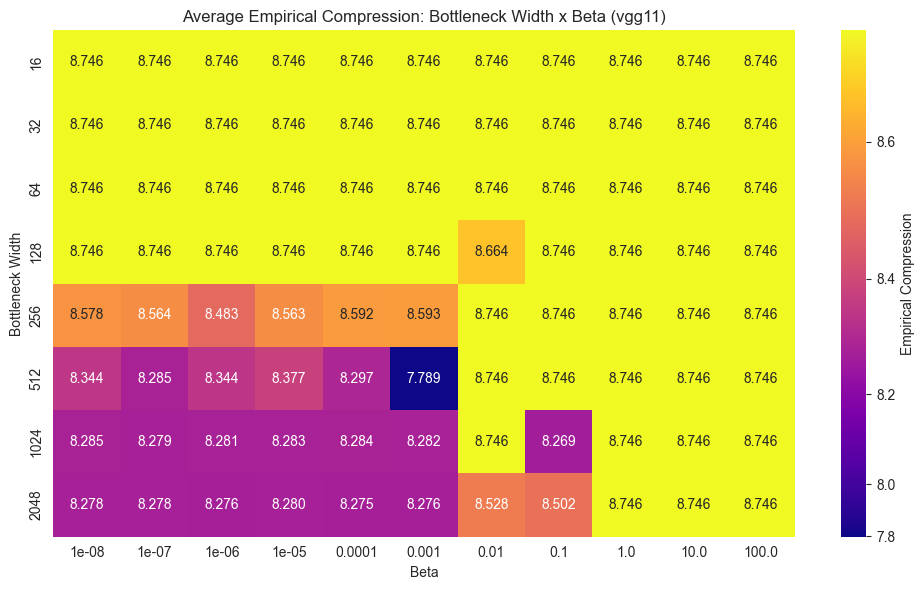

  Saved: heatmap_capacity_vgg11.png


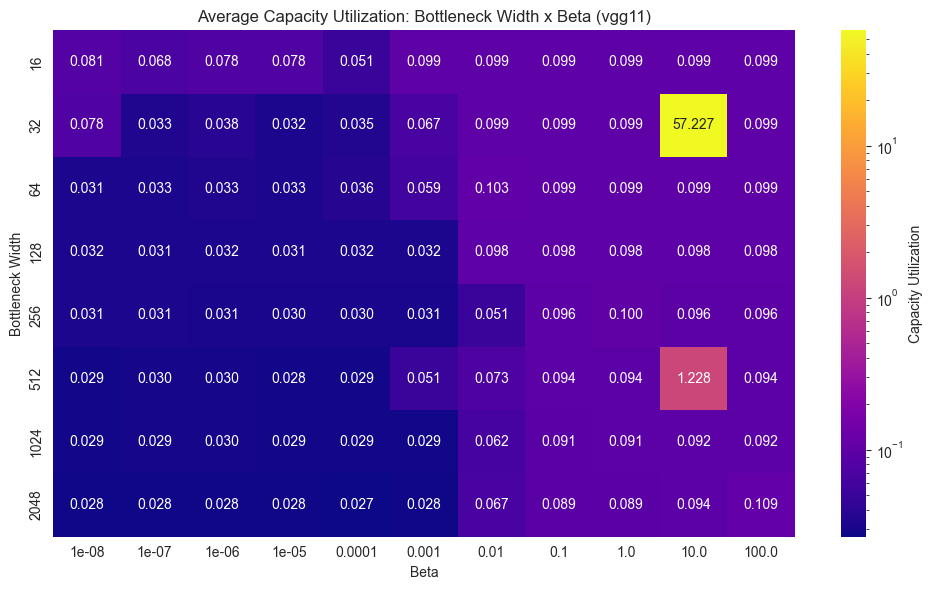

  Saved: scatter_acc_compression_capacity_vgg11.png


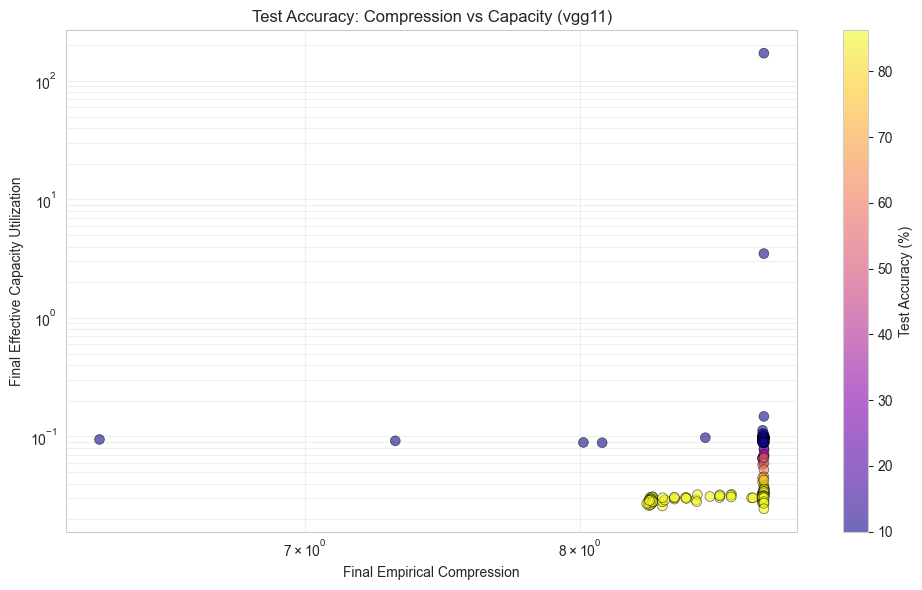

  Saved: scatter_acc_compression_vgg11.png


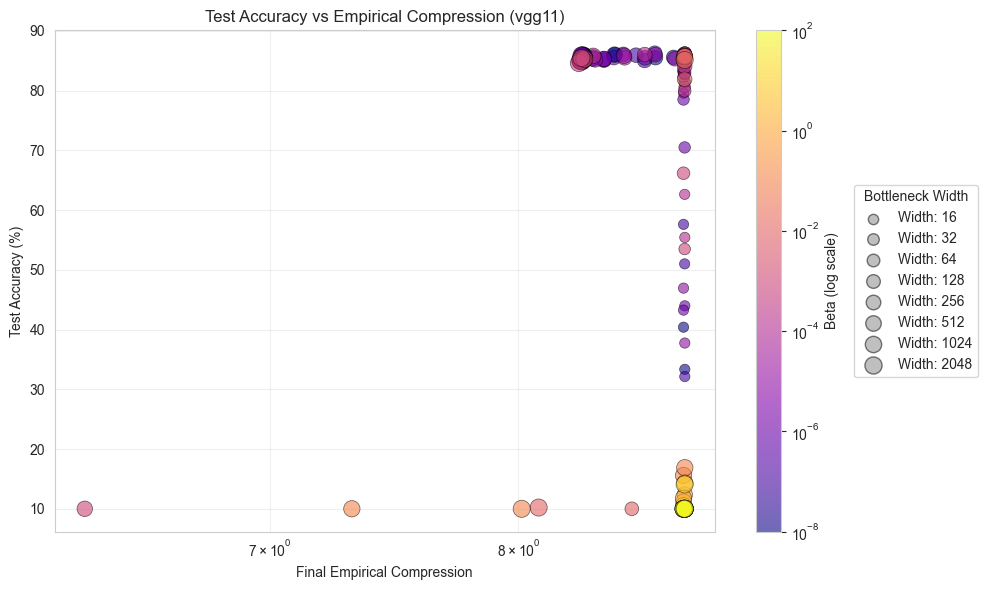

  Saved: accuracy_vs_beta_vgg11.png


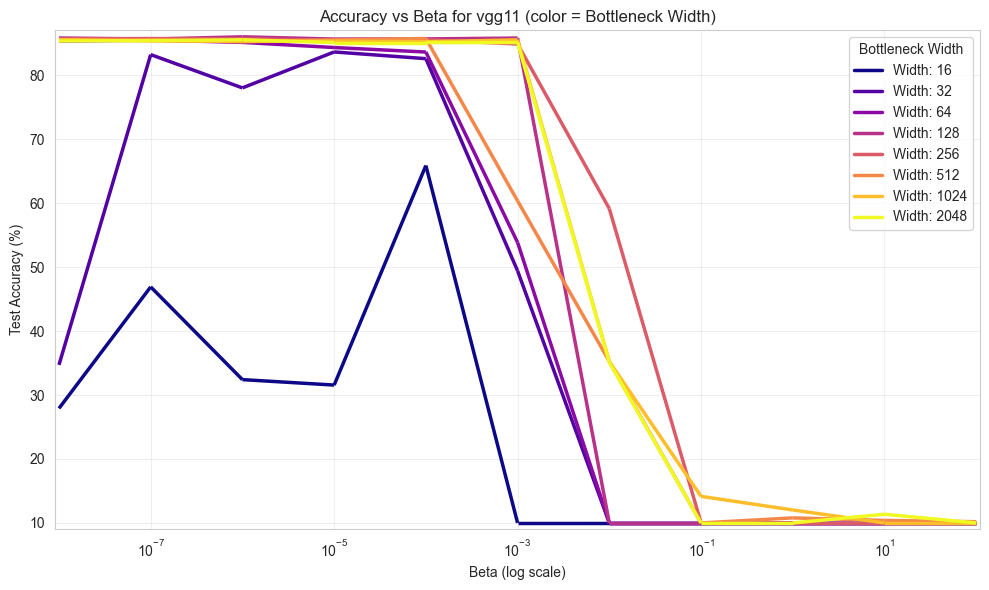

In [21]:
# 7. Analysis by model architecture - separate heatmaps and plots
print('ANALYSIS BY MODEL ARCHITECTURE')

for model_arch in df['model_arch'].unique():
	model_df = df[df['model_arch'] == model_arch].copy()
	model_df_filtered = model_df.copy()

	print(f'\n--- {model_arch} ---')
	print(f'  Experiments: {len(model_df)}')
	print(f'  Mean accuracy: {model_df["test_accuracy"].mean():.2f}%')
	print(f'  Best accuracy: {model_df["test_accuracy"].max():.2f}%')

	# Heatmap for this architecture
	if len(model_df_filtered) > 0:
		# 1. Heatmap: Accuracy
		fig, ax = plt.subplots(figsize=(10, 6))
		pivot_acc = model_df_filtered.pivot_table(
			values='test_accuracy',
			index='bottleneck_width',
			columns='beta',
			aggfunc='mean',
		)
		sns.heatmap(
			pivot_acc,
			annot=True,
			fmt='.1f',
			cmap=BOTTLENECK_CMAP,
			ax=ax,
			cbar_kws={'label': 'Test Accuracy (%)'},
		)
		ax.set_title(f'Average Accuracy: Bottleneck Width x Beta ({model_arch})')
		ax.set_xlabel('Beta')
		ax.set_ylabel('Bottleneck Width')
		plt.tight_layout()
		filename = f'heatmap_accuracy_{model_arch}.png'
		plt.savefig(OUTPUT_DIR / filename, dpi=150)
		print(f'  Saved: {filename}')
		plt.show()

		# 2. Heatmap: Validation Loss
		fig, ax = plt.subplots(figsize=(10, 6))
		pivot_loss = model_df_filtered.pivot_table(
			values='final_val_loss',
			index='bottleneck_width',
			columns='beta',
			aggfunc='mean',
		)
		finite_loss = pivot_loss.values[np.isfinite(pivot_loss.values)]
		if len(finite_loss) > 0:
			vmin_loss = np.min(finite_loss)
			vmax_loss = np.max(finite_loss)
			# Ensure vmin is positive for LogNorm
			if vmin_loss <= 0:
				vmin_loss = vmin_loss * 0.9 if vmin_loss < 0 else vmax_loss * 0.01
			norm_loss = LogNorm(vmin=vmin_loss, vmax=vmax_loss)
			sns.heatmap(
				pivot_loss,
				annot=True,
				fmt='.3f',
				cmap=BOTTLENECK_CMAP,
				ax=ax,
				norm=norm_loss,
				cbar_kws={'label': 'Validation Loss'},
			)
		ax.set_title(f'Average Validation Loss: Bottleneck Width x Beta ({model_arch})')
		ax.set_xlabel('Beta')
		ax.set_ylabel('Bottleneck Width')
		plt.tight_layout()
		filename = f'heatmap_loss_{model_arch}.png'
		plt.savefig(OUTPUT_DIR / filename, dpi=150)
		print(f'  Saved: {filename}')
		plt.show()

		# 3. Heatmap: Empirical Compression
		fig, ax = plt.subplots(figsize=(10, 6))
		pivot_comp = model_df_filtered.pivot_table(
			values='final_empirical_compression',
			index='bottleneck_width',
			columns='beta',
			aggfunc='mean',
		)
		finite_comp = pivot_comp.values[np.isfinite(pivot_comp.values)]
		if len(finite_comp) > 0:
			vmin_comp = np.min(finite_comp)
			vmax_comp = np.max(finite_comp)
			# Ensure vmin is positive for PowerNorm
			if vmin_comp <= 0:
				vmin_comp = vmin_comp * 0.9 if vmin_comp < 0 else vmax_comp * 0.01
			norm_comp = PowerNorm(gamma=1.5, vmin=vmin_comp, vmax=vmax_comp)
			sns.heatmap(
				pivot_comp,
				annot=True,
				fmt='.3f',
				cmap=BOTTLENECK_CMAP,
				ax=ax,
				norm=norm_comp,
				cbar_kws={'label': 'Empirical Compression'},
			)
		ax.set_title(f'Average Empirical Compression: Bottleneck Width x Beta ({model_arch})')
		ax.set_xlabel('Beta')
		ax.set_ylabel('Bottleneck Width')
		plt.tight_layout()
		filename = f'heatmap_compression_{model_arch}.png'
		plt.savefig(OUTPUT_DIR / filename, dpi=150)
		print(f'  Saved: {filename}')
		plt.show()

		# 4. Heatmap: Capacity Utilization
		fig, ax = plt.subplots(figsize=(10, 6))
		pivot_cap = model_df_filtered.pivot_table(
			values='final_effective_capacity_utilization',
			index='bottleneck_width',
			columns='beta',
			aggfunc='mean',
		)
		finite_cap = pivot_cap.values[np.isfinite(pivot_cap.values)]
		if len(finite_cap) > 0:
			vmin_cap = np.min(finite_cap)
			vmax_cap = np.max(finite_cap)
			# Ensure vmin is positive for LogNorm
			if vmin_cap <= 0:
				vmin_cap = vmin_cap * 0.9 if vmin_cap < 0 else vmax_cap * 0.01
			norm_cap = LogNorm(vmin=vmin_cap, vmax=vmax_cap)
			sns.heatmap(
				pivot_cap,
				annot=True,
				fmt='.3f',
				cmap=BOTTLENECK_CMAP,
				ax=ax,
				norm=norm_cap,
				cbar_kws={'label': 'Capacity Utilization'},
			)
		ax.set_title(f'Average Capacity Utilization: Bottleneck Width x Beta ({model_arch})')
		ax.set_xlabel('Beta')
		ax.set_ylabel('Bottleneck Width')
		plt.tight_layout()
		filename = f'heatmap_capacity_{model_arch}.png'
		plt.savefig(OUTPUT_DIR / filename, dpi=150)
		print(f'  Saved: {filename}')
		plt.show()

		# 5. Scatter: Compression vs Capacity (color = accuracy)
		if len(model_df_filtered) > 0:
			fig, ax = plt.subplots(figsize=(10, 6))
			scatter = ax.scatter(
				model_df_filtered['final_empirical_compression'],
				model_df_filtered['final_effective_capacity_utilization'],
				c=model_df_filtered['test_accuracy'],
				cmap=BOTTLENECK_CMAP,
				alpha=0.6,
				s=50,
				edgecolors='black',
				linewidth=0.5,
			)
			ax.set_xlabel('Final Empirical Compression')
			ax.set_ylabel('Final Effective Capacity Utilization')
			ax.set_title(f'Test Accuracy: Compression vs Capacity ({model_arch})')
			ax.set_xscale('log')
			ax.set_yscale('log')
			ax.grid(True, alpha=0.3, which='both')
			cbar = plt.colorbar(scatter)
			cbar.set_label('Test Accuracy (%)')
			plt.tight_layout()
			filename = f'scatter_acc_compression_capacity_{model_arch}.png'
			plt.savefig(OUTPUT_DIR / filename, dpi=150)
			print(f'  Saved: {filename}')
			plt.show()

		# 6. Scatter: Empirical Compression vs Test Accuracy (color = beta, size = width)
		if len(model_df_filtered) > 0:
			fig, ax = plt.subplots(figsize=(10, 6))
			beta_vals = model_df_filtered['beta']
			beta_min = beta_vals.min()
			beta_max = beta_vals.max()
			# Ensure beta_min is positive for LogNorm
			if beta_min <= 0:
				beta_min = beta_min * 0.9 if beta_min < 0 else beta_max * 0.01

			# Scale size by log of bottleneck width
			widths = model_df_filtered['bottleneck_width']
			sizes = np.log(widths) * 20  # Scale factor for visibility

			scatter = ax.scatter(
				model_df_filtered['final_empirical_compression'],
				model_df_filtered['test_accuracy'],
				c=model_df_filtered['beta'],
				norm=LogNorm(beta_min, beta_max),
				cmap=BOTTLENECK_CMAP,
				s=sizes,
				alpha=0.6,
				edgecolors='black',
				linewidth=0.5,
			)
			ax.set_xlabel('Final Empirical Compression')
			ax.set_ylabel('Test Accuracy (%)')
			ax.set_title(f'Test Accuracy vs Empirical Compression ({model_arch})')
			ax.set_xscale('log')
			ax.grid(True, alpha=0.3, which='both')
			cbar = plt.colorbar(scatter)
			cbar.set_label('Beta (log scale)')

			# Add size legend outside the plot near colorbar
			unique_widths = sorted(widths.unique())
			legend_sizes = [np.log(w) * 20 for w in unique_widths]
			legend_handles = [
				plt.scatter(
					[], [], s=s, color='gray', alpha=0.5, edgecolors='black', label=f'Width: {w}'
				)
				for w, s in zip(unique_widths, legend_sizes)
			]
			ax.legend(
				handles=legend_handles,
				title='Bottleneck Width',
				loc='center left',
				bbox_to_anchor=(1.2, 0.5),
			)

			plt.tight_layout()
			filename = f'scatter_acc_compression_{model_arch}.png'
			plt.savefig(OUTPUT_DIR / filename, dpi=150)
			print(f'  Saved: {filename}')
			plt.show()

		# 7. Accuracy vs beta with gradient color
		fig, ax = plt.subplots(figsize=(10, 6))
		plot_accuracy_vs_beta_with_gradient(
			ax, model_df_filtered, f'Accuracy vs Beta for {model_arch} (color = Bottleneck Width)'
		)
		plt.tight_layout()
		filename = f'accuracy_vs_beta_{model_arch}.png'
		plt.savefig(OUTPUT_DIR / filename, dpi=150)
		print(f'  Saved: {filename}')
		plt.show()

In [22]:
# 8. Stability analysis by seed
print('STABILITY ANALYSIS BY SEED')

# For each configuration (model, width, beta) calculate variance by seed
config_variance = df.groupby(['model_arch', 'bottleneck_width', 'beta']).agg(
	{'test_accuracy': ['mean', 'std', 'count']}
)
config_variance.columns = ['mean_acc', 'std_acc', 'count']
config_variance = config_variance[config_variance['count'] >= 2].reset_index()

print('\nConfigurations with highest variance (std) by seed:')
print(
	config_variance.nlargest(10, 'std_acc')[
		['model_arch', 'bottleneck_width', 'beta', 'mean_acc', 'std_acc']
	].round(2)
)

STABILITY ANALYSIS BY SEED

Configurations with highest variance (std) by seed:
    model_arch  bottleneck_width  beta  mean_acc  std_acc
149      vgg11               512  0.01     35.26    43.75
160      vgg11              1024  0.01     35.23    43.69
148      vgg11               512  0.00     60.34    43.60
171      vgg11              2048  0.01     35.11    43.30
99       vgg11                32  0.00     34.71    42.80
138      vgg11               256  0.01     59.14    42.59
18    resnet18                32  0.10     33.10    40.02
115      vgg11                64  0.00     53.85    39.17
104      vgg11                32  0.00     49.41    37.55
63    resnet18               512  1.00     29.70    32.03


In [23]:
# 9. Summary table of best results
print('SUMMARY TABLE OF BEST RESULTS')

summary = df.groupby(['model_arch', 'bottleneck_width', 'beta']).agg(
	{
		'test_accuracy': ['mean', 'std'],
		'final_val_loss': 'mean',
		'final_empirical_compression': 'mean',
	}
)
summary.columns = ['mean_acc', 'std_acc', 'mean_val_loss', 'mean_compression']
summary = summary.round(3)

# Best by average accuracy
best_by_acc = summary.nlargest(15, 'mean_acc')
print('\nTop-15 configurations by average accuracy:')
print(best_by_acc)

# Save to CSV
summary.to_csv(OUTPUT_DIR / 'summary_by_config.csv')
print(f'\nSaved: summary_by_config.csv')

SUMMARY TABLE OF BEST RESULTS

Top-15 configurations by average accuracy:
                                          mean_acc  std_acc  mean_val_loss  \
model_arch bottleneck_width beta                                             
vgg11      128              1.000000e-06    86.003    0.200          0.761   
                            1.000000e-08    85.823    0.205          0.754   
                            1.000000e-03    85.810    0.149          0.742   
           512              1.000000e-04    85.737    0.070          0.708   
           256              1.000000e-07    85.733    0.631          0.746   
                            1.000000e-08    85.687    0.281          0.743   
                            1.000000e-06    85.680    0.330          0.733   
           128              1.000000e-04    85.673    0.464          0.758   
                            1.000000e-05    85.653    0.278          0.739   
                            1.000000e-07    85.650    0.128         

In [24]:
# 10. Final report
print('FINAL REPORT')

best_idx = df['test_accuracy'].idxmax()
best_row = df.loc[best_idx]

print(f"""
BEST RESULT:
   - Test Accuracy: {best_row['test_accuracy']:.2f}%
   - Model: {best_row['model_arch']}
   - Bottleneck Width: {best_row['bottleneck_width']}
   - Beta: {best_row['beta']}
   - Seed: {best_row['seed']}
   - Final Val Loss: {best_row['final_val_loss']:.4f}
   - Final Train Loss: {best_row['final_train_loss']:.4f}

OVERALL STATISTICS:
   - Total experiments: {len(df)}
   - Mean accuracy: {df['test_accuracy'].mean():.2f}%
   - Median accuracy: {df['test_accuracy'].median():.2f}%
   - Best accuracy: {df['test_accuracy'].max():.2f}%
   - Worst accuracy: {df['test_accuracy'].min():.2f}%

RECOMMENDATIONS:
   - Optimal beta range: 0.0001 - 0.01 (most stable results)
   - High beta values (>= 1.0) lead to significant accuracy drop
   - Bottleneck width 32-64 shows best results
""")

# Save final report
report_path = OUTPUT_DIR / 'analysis_report.txt'
with open(report_path, 'w', encoding='utf-8') as f:
	f.write(f'Grid Search Results Analysis\n')
	f.write(f'{"=" * 60}\n\n')
	f.write(f'Total experiments: {len(df)}\n')
	f.write(f'Mean accuracy: {df["test_accuracy"].mean():.2f}%\n')
	f.write(f'Best accuracy: {df["test_accuracy"].max():.2f}%\n\n')
	f.write(f'Best configuration:\n')
	f.write(f'  Model: {best_row["model_arch"]}\n')
	f.write(f'  Width: {best_row["bottleneck_width"]}\n')
	f.write(f'  Beta: {best_row["beta"]}\n')
	f.write(f'  Seed: {best_row["seed"]}\n')
	f.write(f'  Test Accuracy: {best_row["test_accuracy"]:.2f}%\n')

print(f'Saved: analysis_report.txt')
print(f'\nAnalysis complete! Results saved to: results/grid_search/analysis/')

FINAL REPORT

BEST RESULT:
   - Test Accuracy: 86.25%
   - Model: vgg11
   - Bottleneck Width: 256
   - Beta: 1e-07
   - Seed: 1984
   - Final Val Loss: 0.7637
   - Final Train Loss: 0.0348

OVERALL STATISTICS:
   - Total experiments: 528
   - Mean accuracy: 55.18%
   - Median accuracy: 83.16%
   - Best accuracy: 86.25%
   - Worst accuracy: 9.30%

RECOMMENDATIONS:
   - Optimal beta range: 0.0001 - 0.01 (most stable results)
   - High beta values (>= 1.0) lead to significant accuracy drop
   - Bottleneck width 32-64 shows best results

Saved: analysis_report.txt

Analysis complete! Results saved to: results/grid_search/analysis/
